In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "../Scripts")
from util import color_plot

import torch
from deeptime.decomposition.deep import TAE
from deeptime.util.torch import MLP
from deeptime.decomposition.deep import TVAEEncoder
from torch.utils.data import DataLoader
from deeptime.util.data import TrajectoryDataset
from ae import Autoencoder as AE
from vae import VAE

In [2]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

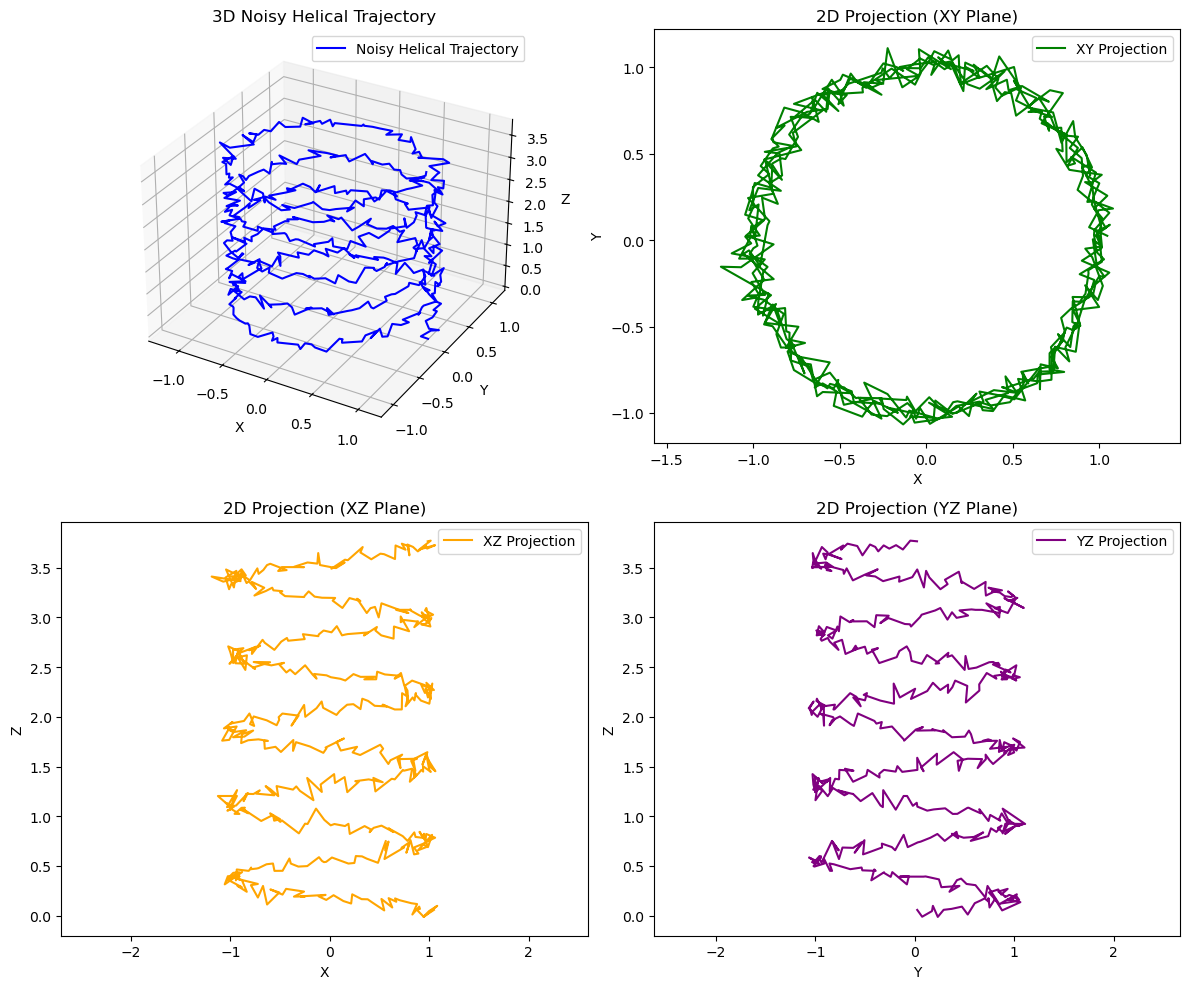

In [3]:
# Function to generate a noisy helical trajectory
def generate_noisy_helix(radius=1.0, pitch=0.75, turns=15, points_per_turn=100, noise_level=0.05):
    t = np.linspace(0, 2 * np.pi * turns, points_per_turn * turns)
    x = radius * np.cos(t) + np.random.normal(0, noise_level, t.shape)
    y = radius * np.sin(t) + np.random.normal(0, noise_level, t.shape)
    z = pitch * t / (2 * np.pi) + np.random.normal(0, noise_level, t.shape)
    return x, y, z

# Function to plot 3D trajectory and its 2D projection
def plot_helix_and_projection(x, y, z):
    fig = plt.figure(figsize=(12, 10))

    # 3D Plot
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.plot(x, y, z, label='Noisy Helical Trajectory', color='blue')
    ax1.set_title('3D Noisy Helical Trajectory')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()

    # 2D Projection (XY plane)
    ax2 = fig.add_subplot(222)
    ax2.plot(x, y, label='XY Projection', color='green')
    ax2.set_title('2D Projection (XY Plane)')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.axis('equal')
    ax2.legend()

    # 2D Projection (XZ plane)
    ax3 = fig.add_subplot(223)
    ax3.plot(x, z, label='XZ Projection', color='orange')
    ax3.set_title('2D Projection (XZ Plane)')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.axis('equal')
    ax3.legend()

    # 2D Projection (YZ plane)
    ax4 = fig.add_subplot(224)
    ax4.plot(y, z, label='YZ Projection', color='purple')
    ax4.set_title('2D Projection (YZ Plane)')
    ax4.set_xlabel('Y')
    ax4.set_ylabel('Z')
    ax4.axis('equal')
    ax4.legend()

    plt.tight_layout()
    plt.show()

# Generate and plot
x, y, z = generate_noisy_helix(turns=5)
plot_helix_and_projection(x, y, z)

In [4]:
## helical trajectory data
x, y, z = generate_noisy_helix(turns = 20)
data = np.column_stack([x, y, z])
scaler = MinMaxScaler()
data = scaler.fit_transform(data)
data = torch.Tensor(data)

# dataset = Dataset(1, data.astype(np.float32))
n_val = int(len(data)*.25)
train_data, val_data = torch.utils.data.random_split(data, [len(data) - n_val, n_val])
loader_train = DataLoader(train_data, batch_size=16, shuffle=True)
loader_val = DataLoader(val_data, batch_size=len(val_data), shuffle=True)

Epoch 1/1000: Val loss improved to 145.5512. Saving model.
Epoch 2/1000: Val loss improved to 139.2833. Saving model.
Epoch 3/1000: Val loss improved to 106.8749. Saving model.
Epoch 4/1000: Val loss improved to 96.7968. Saving model.
Epoch 5/1000: Val loss improved to 51.6735. Saving model.
Epoch 6/1000: Val loss improved to 44.7238. Saving model.
Epoch 7/1000: Val loss improved to 40.2749. Saving model.
Epoch 8/1000: Val loss improved to 38.1573. Saving model.
Epoch 9/1000: Val loss improved to 34.2346. Saving model.
Epoch 10/1000: Val loss improved to 31.7314. Saving model.
Epoch 11/1000: Val loss improved to 29.5097. Saving model.
Epoch 12/1000: Val loss improved to 28.2151. Saving model.
Epoch 13/1000: Val loss improved to 27.3301. Saving model.
Epoch 14/1000: Val loss improved to 25.7068. Saving model.
Epoch 15/1000: Val loss improved to 23.9933. Saving model.
Epoch 16/1000: Val loss did not improve from 23.9933. Patience: 1/10
Epoch 17/1000: Val loss improved to 20.7078. Saving 

<Axes: >

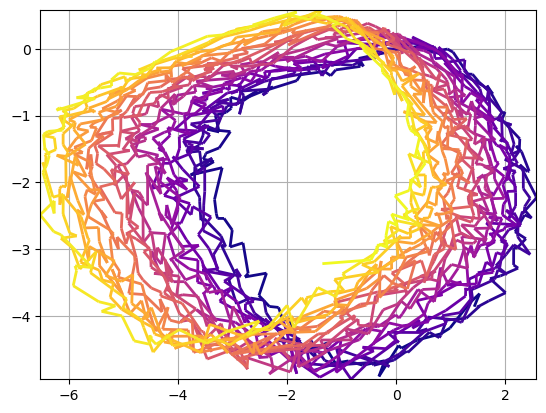

In [8]:
units = [3, 24, 24, 2] # input, hidden1, hidden2, output

encoder = TVAEEncoder(units, nonlinearity=torch.nn.ReLU)
decoder = MLP(units[::-1], nonlinearity=torch.nn.ReLU, initial_batchnorm=False)

vae = VAE(encoder, decoder, learning_rate=1e-3, beta=0.0, device='cuda')
vae.fit(loader_train, n_epochs=1000, validation_loader=loader_val)
vae_model = vae.fetch_model()

color_plot(vae_model.get_latent_parameters(data)[0][:,0],
         vae_model.get_latent_parameters(data)[0][:,1])

Epoch 1/150: Val loss improved to 142.7758. Saving model.
Epoch 2/150: Val loss improved to 47.4097. Saving model.
Epoch 3/150: Val loss improved to 37.4778. Saving model.
Epoch 4/150: Val loss improved to 30.1940. Saving model.
Epoch 5/150: Val loss improved to 19.7694. Saving model.
Epoch 6/150: Val loss improved to 17.0196. Saving model.
Epoch 7/150: Val loss improved to 14.8519. Saving model.
Epoch 8/150: Val loss did not improve from 14.8519. Patience: 1/10
Epoch 9/150: Val loss improved to 14.6439. Saving model.
Epoch 10/150: Val loss improved to 13.6009. Saving model.
Epoch 11/150: Val loss improved to 12.3139. Saving model.
Epoch 12/150: Val loss improved to 12.2968. Saving model.
Epoch 13/150: Val loss improved to 10.7377. Saving model.
Epoch 14/150: Val loss did not improve from 10.7377. Patience: 1/10
Epoch 15/150: Val loss improved to 9.9490. Saving model.
Epoch 16/150: Val loss improved to 9.1900. Saving model.
Epoch 17/150: Val loss did not improve from 9.1900. Patience: 

<Axes: >

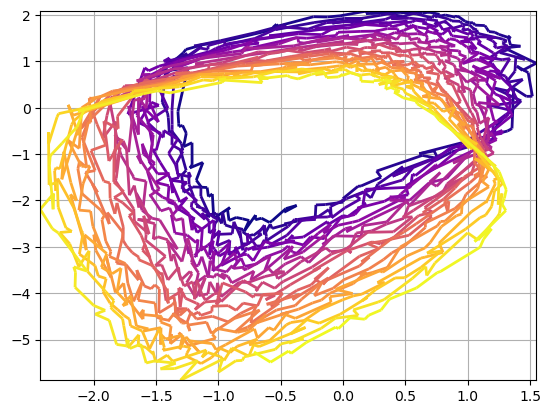

In [9]:
units = [3, 64, 64, 2] # input, hidden1, hidden2, output

encoder = TVAEEncoder(units, nonlinearity=torch.nn.ReLU)
decoder = MLP(units[::-1], nonlinearity=torch.nn.ReLU, initial_batchnorm=False)

vae = VAE(encoder, decoder, learning_rate=1e-3, beta=0.0, device='cuda')
vae.fit(loader_train, n_epochs=150, validation_loader=loader_val)
vae_model = vae.fetch_model()
color_plot(vae_model.get_latent_parameters(data)[0][:,0],
         vae_model.get_latent_parameters(data)[0][:,1])

Epoch 1/150: Val loss improved to 167.6720. Saving model.
Epoch 2/150: Val loss improved to 148.8573. Saving model.
Epoch 3/150: Val loss improved to 143.7561. Saving model.
Epoch 4/150: Val loss improved to 140.0548. Saving model.
Epoch 5/150: Val loss improved to 135.7714. Saving model.
Epoch 6/150: Val loss did not improve from 135.7714. Patience: 1/10
Epoch 7/150: Val loss did not improve from 135.7714. Patience: 2/10
Epoch 8/150: Val loss improved to 125.2016. Saving model.
Epoch 9/150: Val loss improved to 119.2061. Saving model.
Epoch 10/150: Val loss improved to 109.8306. Saving model.
Epoch 11/150: Val loss improved to 98.4962. Saving model.
Epoch 12/150: Val loss improved to 95.0782. Saving model.
Epoch 13/150: Val loss improved to 91.8562. Saving model.
Epoch 14/150: Val loss improved to 84.9107. Saving model.
Epoch 15/150: Val loss improved to 48.0057. Saving model.
Epoch 16/150: Val loss improved to 36.2777. Saving model.
Epoch 17/150: Val loss improved to 32.1254. Saving 

<Axes: >

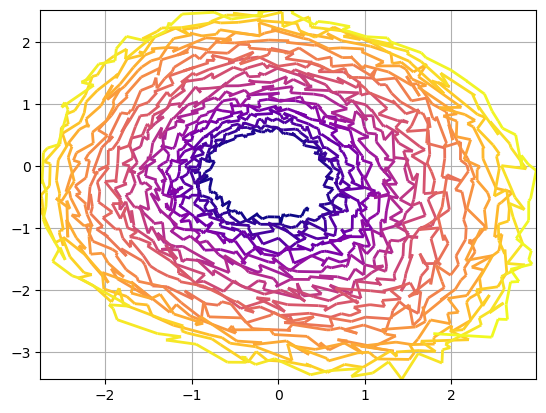

In [10]:
units = [3, 128, 128, 2] # input, hidden1, hidden2, output

encoder = TVAEEncoder(units, nonlinearity=torch.nn.ReLU)
decoder = MLP(units[::-1], nonlinearity=torch.nn.ReLU, initial_batchnorm=False)

vae = VAE(encoder, decoder, learning_rate=1e-4, beta=0.0, device='cuda')
vae.fit(loader_train, n_epochs=150, validation_loader=loader_val)
vae_model = vae.fetch_model()
color_plot(vae_model.get_latent_parameters(data)[0][:,0],
         vae_model.get_latent_parameters(data)[0][:,1])

## Same architecture but converges to two solutions!!

Epoch 1/150: Val loss improved to 33.7988. Saving model.
Epoch 2/150: Val loss improved to 4.7125. Saving model.
Epoch 3/150: Val loss improved to 1.9242. Saving model.
Epoch 4/150: Val loss improved to 1.5503. Saving model.
Epoch 5/150: Val loss did not improve from 1.5503. Patience: 1/10
Epoch 6/150: Val loss did not improve from 1.5503. Patience: 2/10
Epoch 7/150: Val loss did not improve from 1.5503. Patience: 3/10
Epoch 8/150: Val loss did not improve from 1.5503. Patience: 4/10
Epoch 9/150: Val loss did not improve from 1.5503. Patience: 5/10
Epoch 10/150: Val loss improved to 1.4405. Saving model.
Epoch 11/150: Val loss did not improve from 1.4405. Patience: 1/10
Epoch 12/150: Val loss improved to 1.1546. Saving model.
Epoch 13/150: Val loss did not improve from 1.1546. Patience: 1/10
Epoch 14/150: Val loss improved to 0.9846. Saving model.
Epoch 15/150: Val loss did not improve from 0.9846. Patience: 1/10
Epoch 16/150: Val loss did not improve from 0.9846. Patience: 2/10
Epoch 

<Axes: >

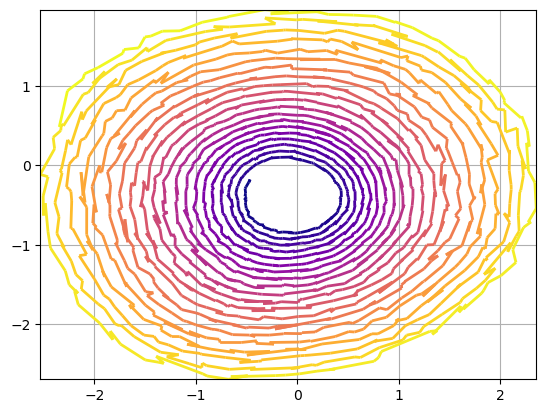

In [11]:
units = [3, 512, 512, 2] # input, hidden1, hidden2, output

encoder = TVAEEncoder(units, nonlinearity=torch.nn.ReLU)
decoder = MLP(units[::-1], nonlinearity=torch.nn.ReLU, initial_batchnorm=False)

vae = VAE(encoder, decoder, learning_rate=1e-3, beta=0.0, device='cuda')
vae.fit(loader_train, n_epochs=150, validation_loader=loader_val)
vae_model = vae.fetch_model()

color_plot(vae_model.get_latent_parameters(data)[0][:,0],
         vae_model.get_latent_parameters(data)[0][:,1])

Epoch 1/150: Val loss improved to 130.4995. Saving model.
Epoch 2/150: Val loss improved to 42.2943. Saving model.
Epoch 3/150: Val loss improved to 29.7727. Saving model.
Epoch 4/150: Val loss improved to 19.8520. Saving model.
Epoch 5/150: Val loss improved to 12.7216. Saving model.
Epoch 6/150: Val loss improved to 11.0988. Saving model.
Epoch 7/150: Val loss improved to 10.0084. Saving model.
Epoch 8/150: Val loss improved to 8.7816. Saving model.
Epoch 9/150: Val loss improved to 8.4742. Saving model.
Epoch 10/150: Val loss improved to 8.0227. Saving model.
Epoch 11/150: Val loss improved to 6.8497. Saving model.
Epoch 12/150: Val loss improved to 6.6917. Saving model.
Epoch 13/150: Val loss did not improve from 6.6917. Patience: 1/10
Epoch 14/150: Val loss improved to 6.2760. Saving model.
Epoch 15/150: Val loss did not improve from 6.2760. Patience: 1/10
Epoch 16/150: Val loss did not improve from 6.2760. Patience: 2/10
Epoch 17/150: Val loss improved to 5.8592. Saving model.
Ep

<Axes: >

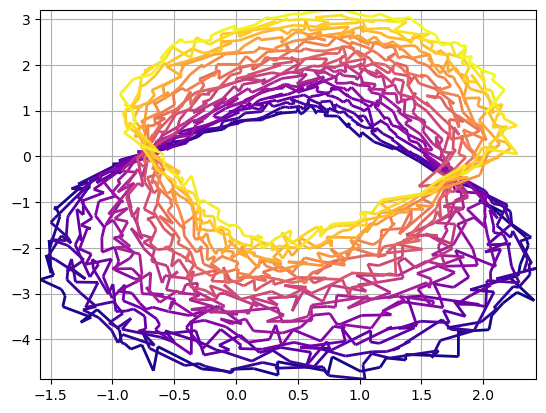

In [12]:
units = [3, 512, 512, 2] # input, hidden1, hidden2, output

encoder = TVAEEncoder(units, nonlinearity=torch.nn.ReLU)
decoder = MLP(units[::-1], nonlinearity=torch.nn.ReLU, initial_batchnorm=False)

vae = VAE(encoder, decoder, learning_rate=1e-4, beta=0.0, device='cuda')
vae.fit(loader_train, n_epochs=150, validation_loader=loader_val)
vae_model = vae.fetch_model()

color_plot(vae_model.get_latent_parameters(data)[0][:,0],
         vae_model.get_latent_parameters(data)[0][:,1])

## Tuning beta of beta-VAE

In [ ]:
units = [3, 512, 512, 2] # input, hidden1, hidden2, output

encoder = TVAEEncoder(units, nonlinearity=torch.nn.ReLU)
decoder = MLP(units[::-1], nonlinearity=torch.nn.ReLU, initial_batchnorm=False)

vae = VAE(encoder, decoder, learning_rate=1e-4, beta=0.1, device='cuda')
vae.fit(loader_train, n_epochs=150, validation_loader=loader_val)
vae_model = vae.fetch_model()
color_plot(vae_model.get_latent_parameters(data)[0][:,0],
         vae_model.get_latent_parameters(data)[0][:,1])

Epoch 1/150: Val loss improved to 148.6052. Saving model.
Epoch 2/150: Val loss improved to 137.5054. Saving model.
Epoch 3/150: Val loss improved to 136.1423. Saving model.
Epoch 4/150: Val loss did not improve from 136.1423. Patience: 1/10
Epoch 5/150: Val loss improved to 133.9338. Saving model.
Epoch 6/150: Val loss did not improve from 133.9338. Patience: 1/10
Epoch 7/150: Val loss improved to 130.3414. Saving model.
Epoch 8/150: Val loss did not improve from 130.3414. Patience: 1/10
Epoch 9/150: Val loss improved to 129.6019. Saving model.
Epoch 10/150: Val loss improved to 129.2631. Saving model.
Epoch 11/150: Val loss improved to 123.1847. Saving model.
Epoch 12/150: Val loss did not improve from 123.1847. Patience: 1/10
Epoch 13/150: Val loss did not improve from 123.1847. Patience: 2/10
Epoch 14/150: Val loss did not improve from 123.1847. Patience: 3/10
Epoch 15/150: Val loss improved to 119.0900. Saving model.
Epoch 16/150: Val loss did not improve from 119.0900. Patience: 

Epoch 1/150: Val loss improved to 148.2911. Saving model.
Epoch 2/150: Val loss improved to 145.2763. Saving model.
Epoch 3/150: Val loss did not improve from 145.2763. Patience: 1/10
Epoch 4/150: Val loss improved to 144.1458. Saving model.
Epoch 5/150: Val loss improved to 144.0872. Saving model.
Epoch 6/150: Val loss did not improve from 144.0872. Patience: 1/10
Epoch 7/150: Val loss did not improve from 144.0872. Patience: 2/10
Epoch 8/150: Val loss did not improve from 144.0872. Patience: 3/10
Epoch 9/150: Val loss did not improve from 144.0872. Patience: 4/10
Epoch 10/150: Val loss improved to 143.7211. Saving model.
Epoch 11/150: Val loss did not improve from 143.7211. Patience: 1/10
Epoch 12/150: Val loss improved to 143.1161. Saving model.
Epoch 13/150: Val loss did not improve from 143.1161. Patience: 1/10
Epoch 14/150: Val loss improved to 142.3249. Saving model.
Epoch 15/150: Val loss did not improve from 142.3249. Patience: 1/10
Epoch 16/150: Val loss did not improve from 

<Axes: >

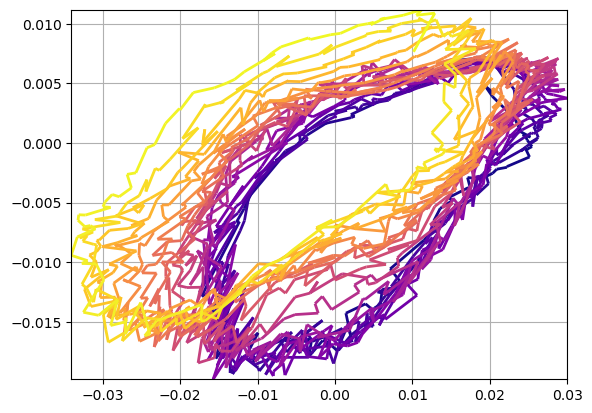

In [13]:
units = [3, 512, 512, 2] # input, hidden1, hidden2, output

encoder = TVAEEncoder(units, nonlinearity=torch.nn.ReLU)
decoder = MLP(units[::-1], nonlinearity=torch.nn.ReLU, initial_batchnorm=False)

vae = VAE(encoder, decoder, learning_rate=1e-4, beta=0.5, device='cuda')
vae.fit(loader_train, n_epochs=150, validation_loader=loader_val)
vae_model = vae.fetch_model()
color_plot(vae_model.get_latent_parameters(data)[0][:,0],
         vae_model.get_latent_parameters(data)[0][:,1])

In [ ]:

encoder = MLP(units, nonlinearity=torch.nn.ReLU)
decoder = MLP(units[::-1], nonlinearity=torch.nn.ReLU, initial_batchnorm=False)
ae = AE(encoder, decoder, learning_rate=1e-4, device='cuda')
ae.fit(loader_train, n_epochs=250, validation_loader=loader_val)
ae_model = ae.fetch_model()
proj = ae_model.transform(data)
# fig, ax = plt.subplots(figsize=(8, 6))
color_plot(proj[:, 0], proj[:, 1])
#plt.xlim(-0.1, 1.01)
#plt.ylim(0.0, 0.9)
plt.xlabel(r"$\mu_1$")
plt.ylabel(r"$\mu_2$")